In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim

In [4]:
trainset = torchvision.datasets.FashionMNIST(
    root='data/', train = True, download = True, 
    transform = transforms.ToTensor()
)

Using downloaded and verified file: data/FashionMNIST/raw/train-images-idx3-ubyte.gz
Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw

Using downloaded and verified file: data/FashionMNIST/raw/train-labels-idx1-ubyte.gz
Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw

Using downloaded and verified file: data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz
Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 2.64MB/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [5]:
batch_size = 4
trainloader = torch.utils.data.DataLoader(trainset, batch_size = batch_size, 
                                          shuffle = True)

In [7]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)
print(images[0].shape)
print(labels[0].item())

torch.Size([4, 1, 28, 28])
torch.Size([1, 28, 28])
6


In [8]:
def imshow(img, title):
    plt.figure(figsize = (batch_size * 4, 4))
    plt.axis('off')
    plt.imshow(np.transpose(img, (1, 2,0)))
    plt.title(title)
    plt.show()

In [9]:
def show_batch_images(dataloader):
    # image 크기: (4, 28, 28, 1); (batch size, height, width, channel)
    images, labels = next(iter(dataloader)) 
    
    # 좌표에 이미지 픽셀을 대응시켜 그리드 형태로 출력
    img = torchvision.utils.make_grid(images) 
    # imshow 함수를 사용함으로써 데이터 형태가 (channel, height, width) -> (height, width, channle)로
    imshow(img, title=[str(x.item()) for x in labels])

    return images, labels

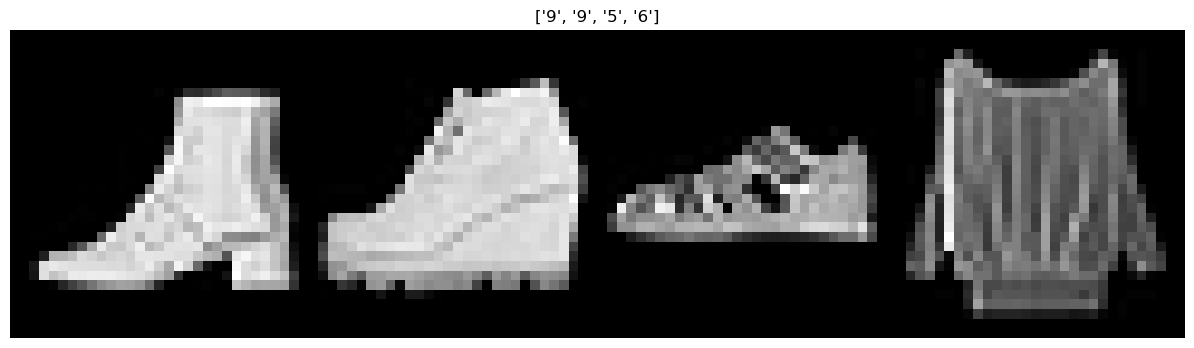

In [10]:
images, labels = show_batch_images(trainloader)

In [11]:
class NormalNet(nn.Module):
    def __init__(self):
        super(NormalNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48), # (28 * 28) = 784 -> 48 nodes
            nn.ReLU(), 
            nn.Linear(48, 24), # 48 -> 24 nodes
            nn.ReLU(), 
            nn.Linear(24, 10) # FashionMNIST: 10 classes
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
        return x

In [12]:
class BNNet(nn.Module):
    def __init__(self):
        super(BNNet, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(784, 48), # (28 * 28) = 784 -> 48 nodes
            nn.BatchNorm1d(48), 
            nn.ReLU(), 
            nn.Linear(48, 24), # 48 -> 24 nodes
            nn.BatchNorm1d(24), 
            nn.ReLU(), 
            nn.Linear(24, 10) # FashionMNIST: 10 classes
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.classifier(x) # nn.Sequential에서 정의한 계층 호출
        return x

In [13]:
model = NormalNet()
print(model)

NormalNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): ReLU()
    (2): Linear(in_features=48, out_features=24, bias=True)
    (3): ReLU()
    (4): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [14]:
model_bn = BNNet()
print(model_bn)

BNNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=48, bias=True)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Linear(in_features=48, out_features=24, bias=True)
    (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Linear(in_features=24, out_features=10, bias=True)
  )
)


In [15]:
batch_size = 512
trainloader = torch.utils.data.DataLoader(trainset, 
                                          batch_size = batch_size, shuffle = True)

In [25]:
loss_fn = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr = 0.01)
opt_bn = optim.SGD(model_bn.parameters(), lr = 0.01)

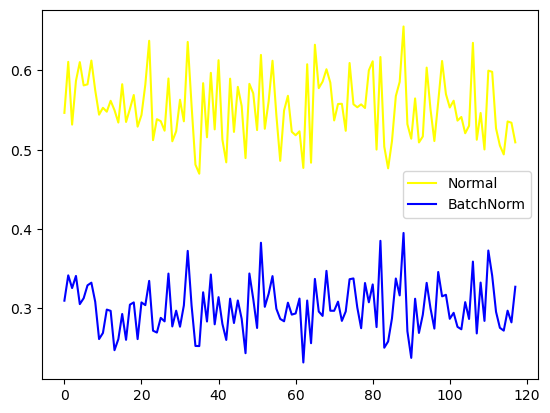

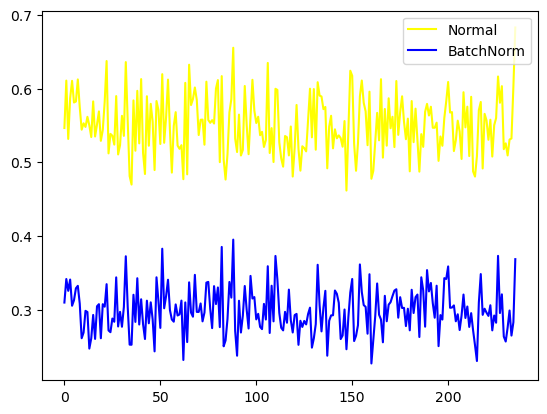

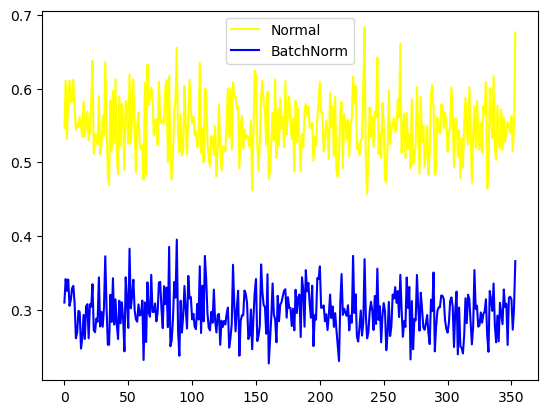

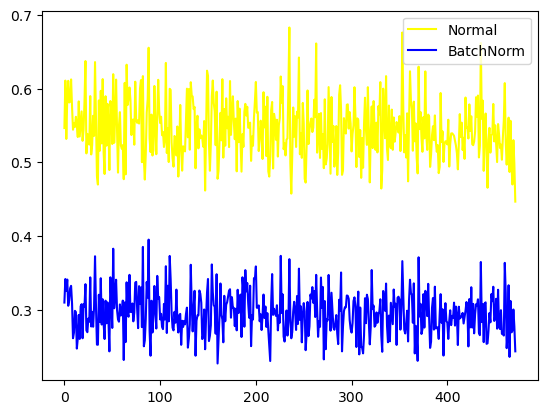

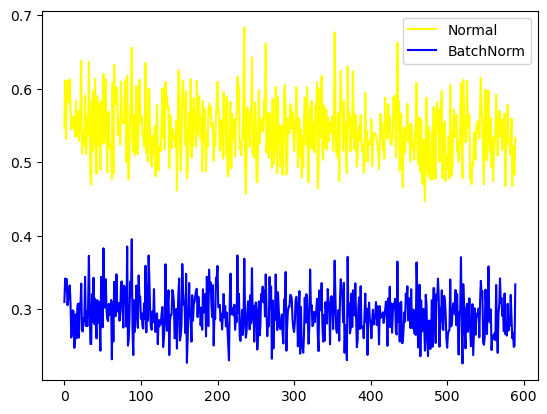

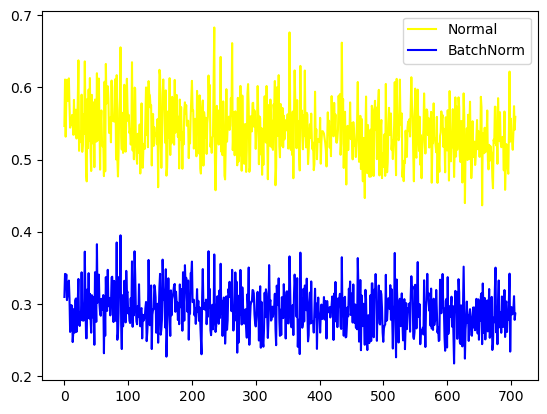

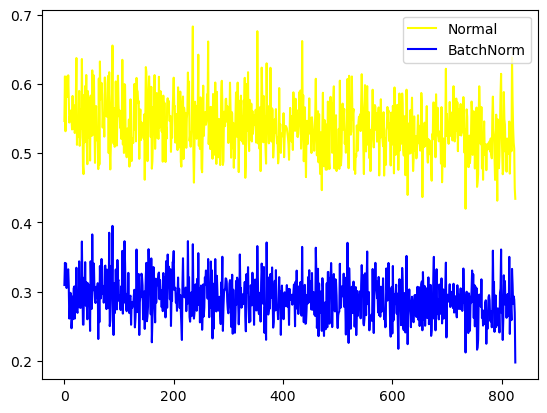

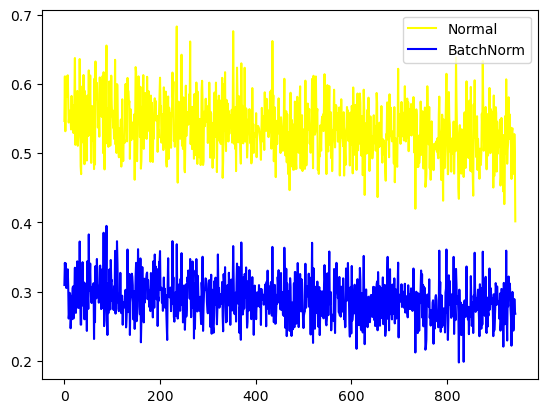

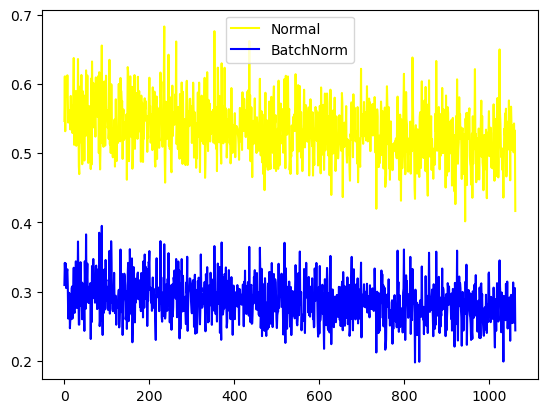

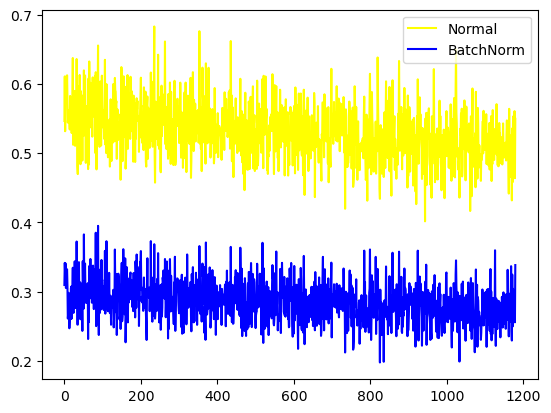

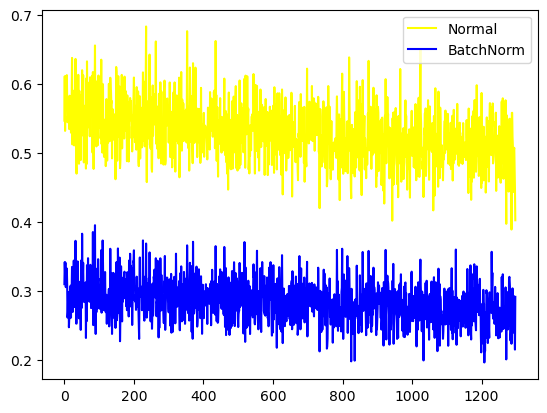

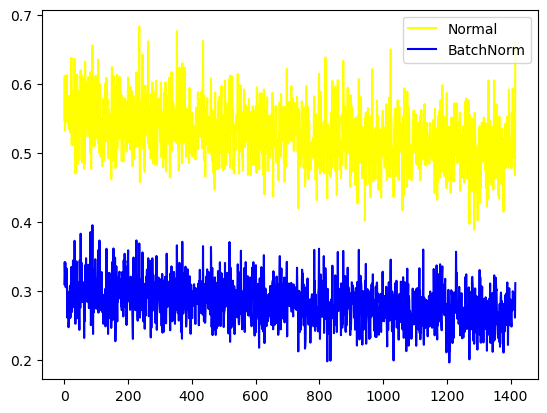

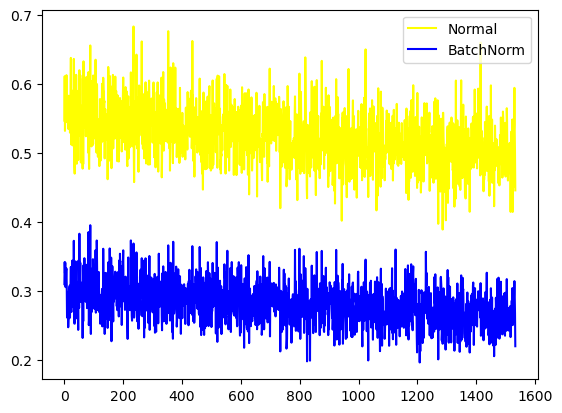

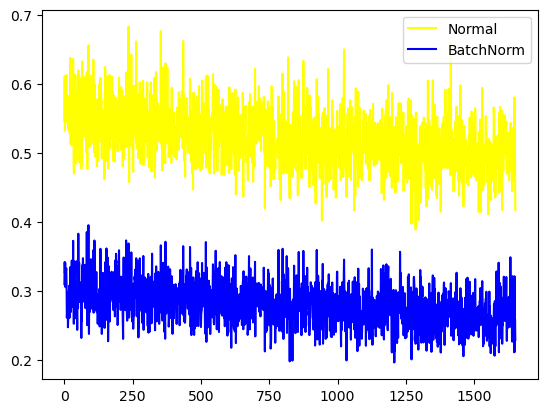

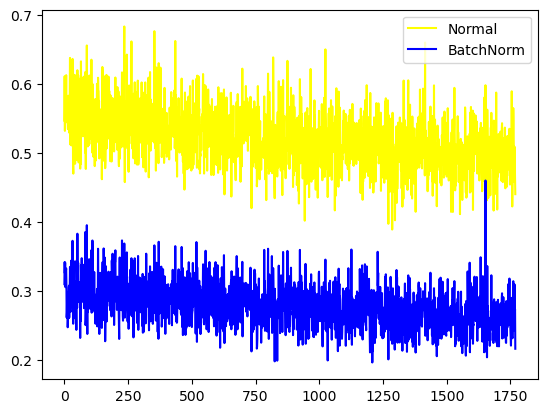

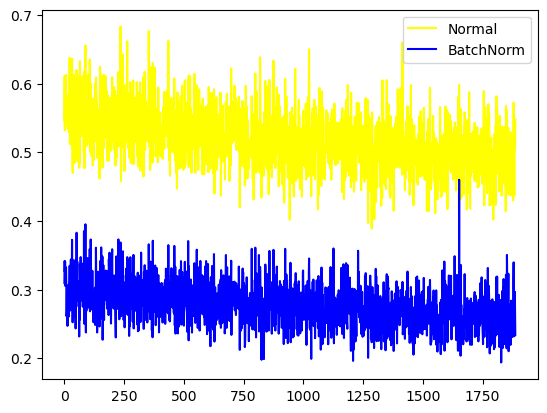

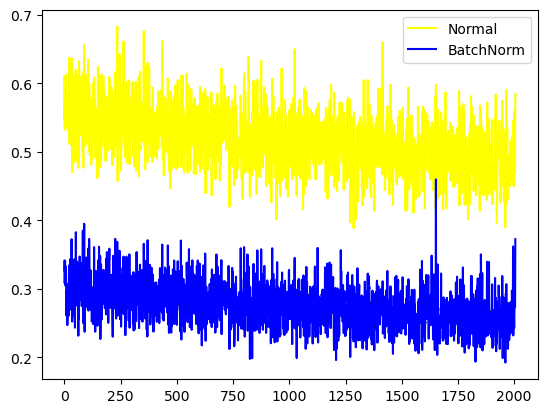

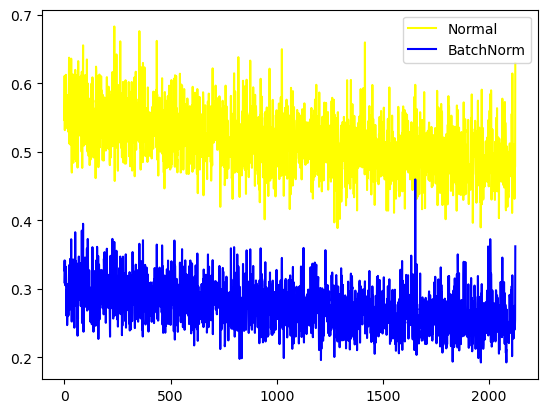

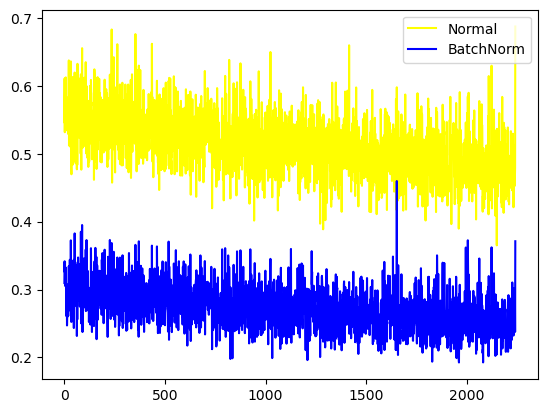

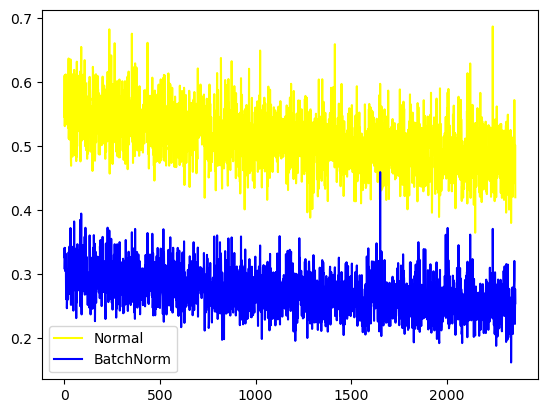

In [26]:
loss_arr = []
loss_bn_arr = []
max_epochs = 20

for epoch in range(max_epochs):
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        opt.zero_grad() # BN 적용 x model train
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt.step()

        opt_bn.zero_grad() # BN 적용 model train
        outputs_bn = model_bn(inputs)
        loss_bn = loss_fn(outputs_bn, labels)
        loss_bn.backward()
        opt_bn.step()

        loss_arr.append(loss.item())
        loss_bn_arr.append(loss_bn.item())

    plt.plot(loss_arr, 'yellow', label = 'Normal')
    plt.plot(loss_bn_arr, 'blue', label = 'BatchNorm')
    plt.legend()
    plt.show()

In [27]:
N = 50
noise = 0.3

x_train = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_train = x_train + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

x_test = torch.unsqueeze(torch.linspace(-1, 1, N), 1)
y_test = x_test + noise * torch.normal(torch.zeros(N, 1), torch.ones(N, 1))

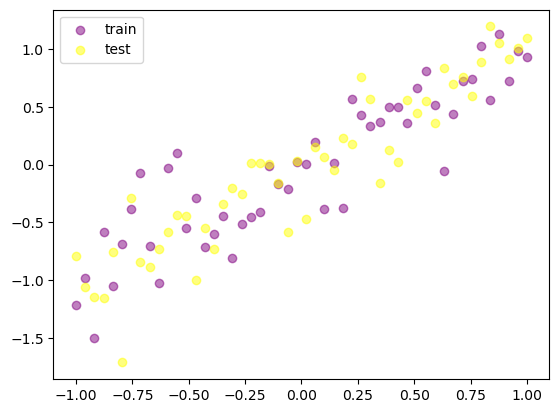

In [28]:
plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c= 'purple', 
            alpha=0.5, label = 'train')
plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c= 'yellow', 
            alpha=0.5, label = 'test')
plt.legend()
plt.show()

In [29]:
N_h = 100
model = torch.nn.Sequential(
    torch.nn.Linear(1, N_h), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, N_h), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, 1)
) # Dropout x

model_dropout = torch.nn.Sequential(
    torch.nn.Linear(1, N_h), 
    torch.nn.Dropout(0.2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, N_h), 
    torch.nn.Dropout(0.2), 
    torch.nn.ReLU(), 
    torch.nn.Linear(N_h, 1)
) # Dropout o

In [30]:
opt = torch.optim.Adam(model.parameters(), lr = 0.01)
opt_dropout = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
loss_fn = torch.nn.MSELoss()

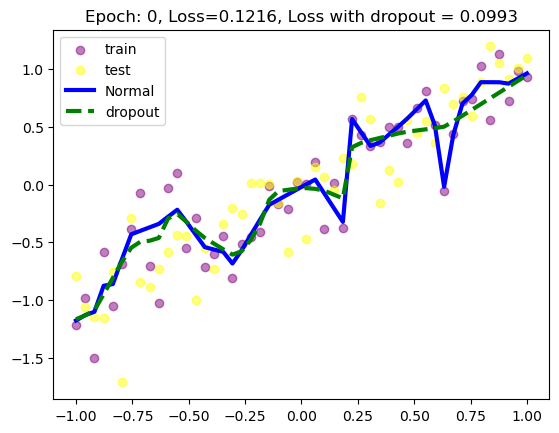

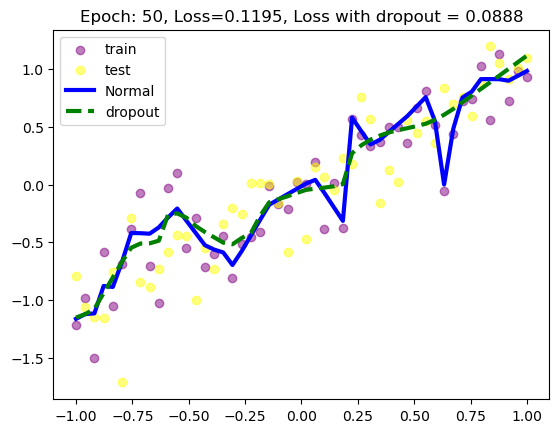

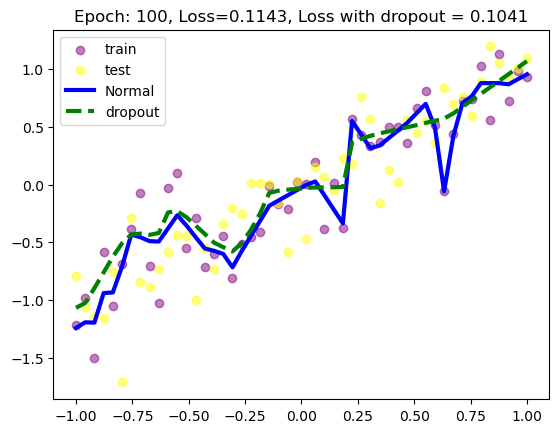

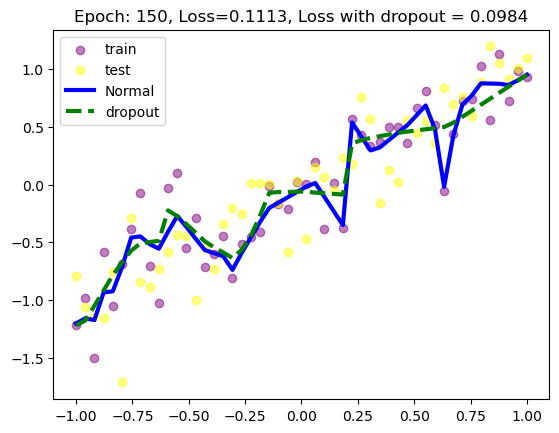

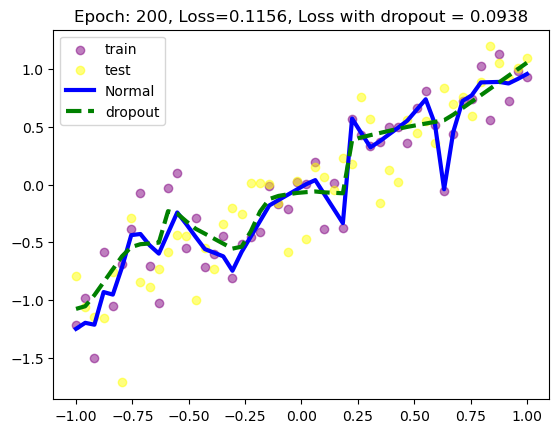

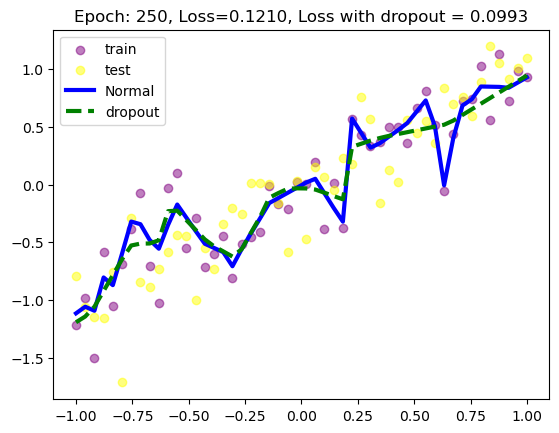

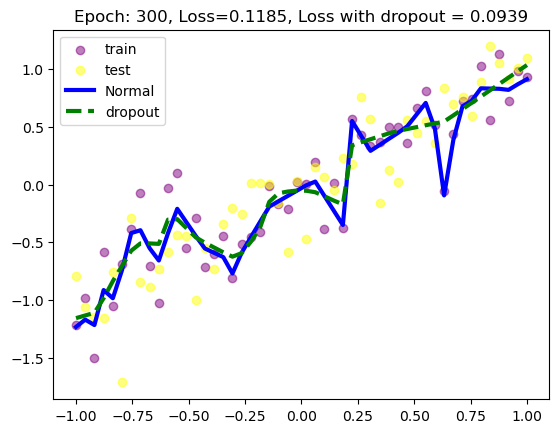

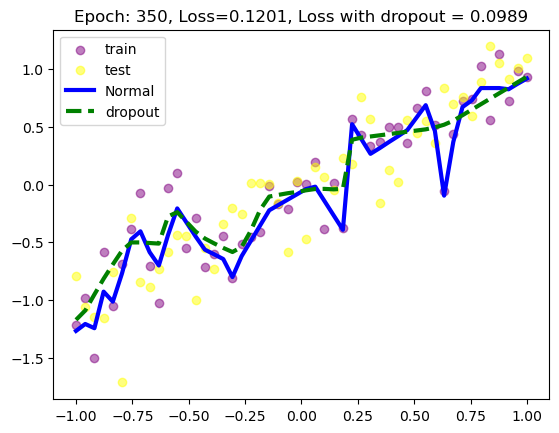

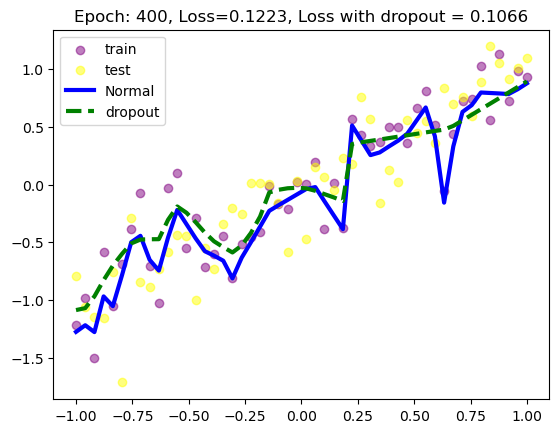

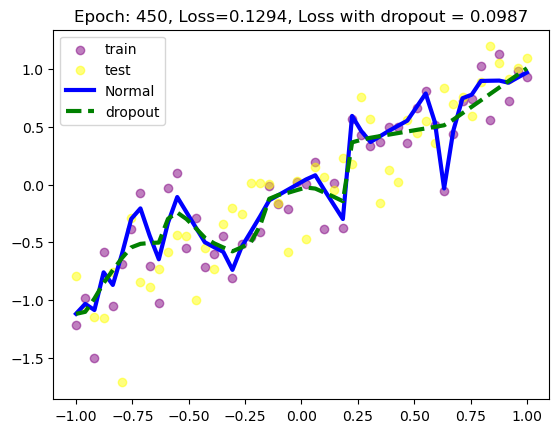

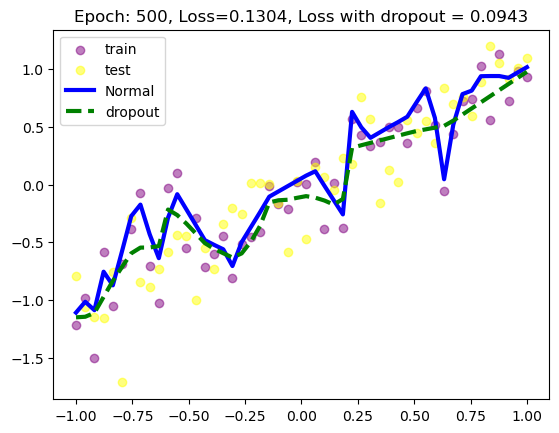

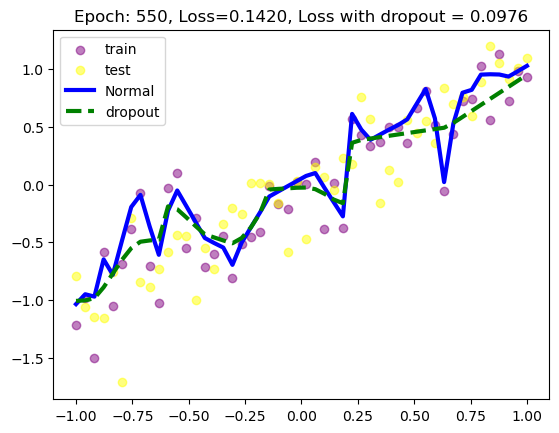

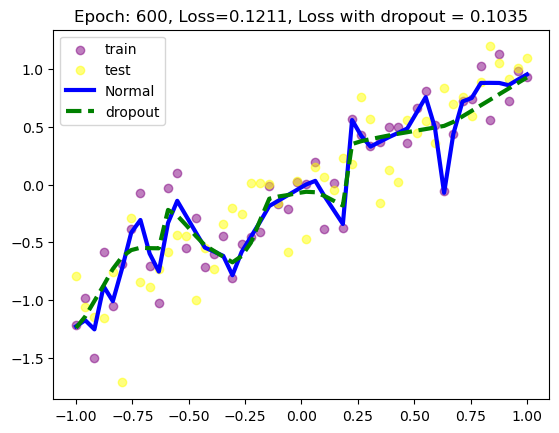

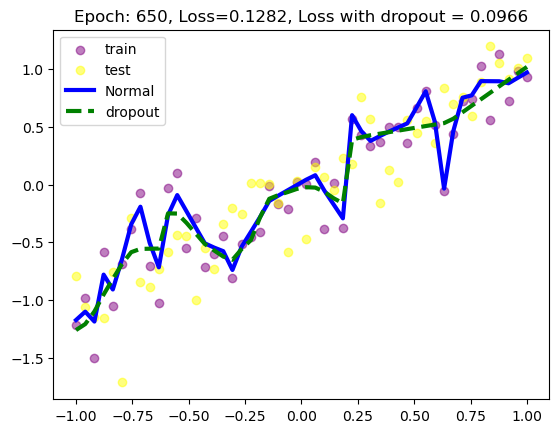

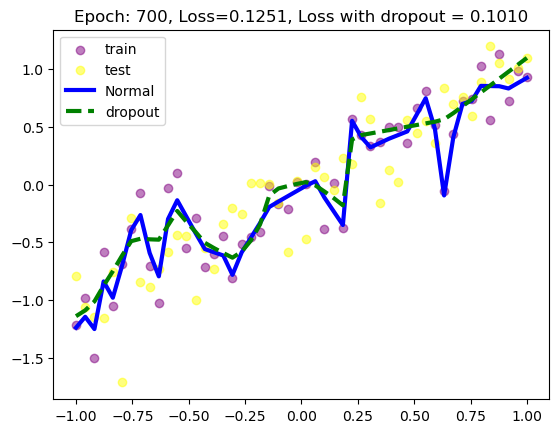

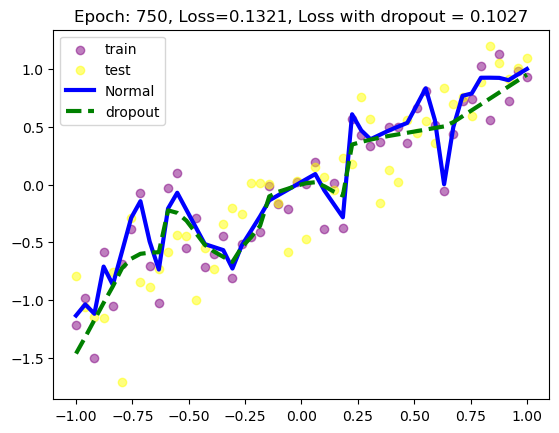

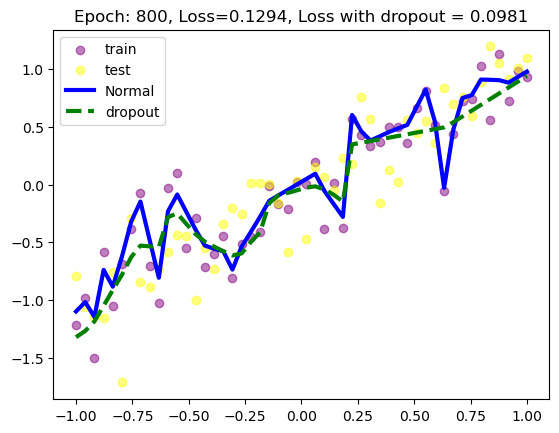

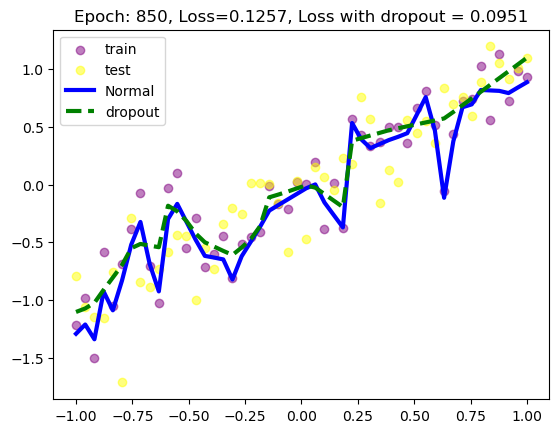

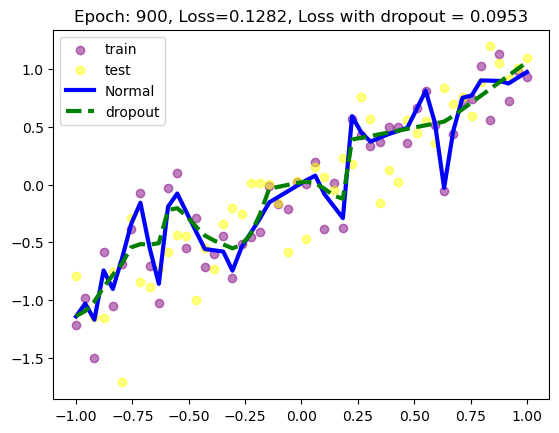

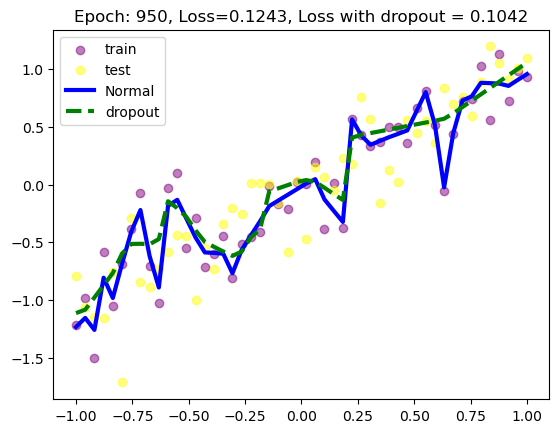

In [35]:
max_epochs = 1000
for epoch in range(max_epochs):
    pred = model(x_train)
    loss = loss_fn(pred, y_train)
    opt.zero_grad()
    loss.backward()
    opt.step()

    pred_dropout = model_dropout(x_train)
    loss_dropout = loss_fn(pred_dropout, y_train)
    opt_dropout.zero_grad()
    loss_dropout.backward()
    opt_dropout.step()

    if epoch % 50 == 0:
        model.eval()
        model_dropout.eval()

        test_pred = model(x_test)
        test_loss = loss_fn(test_pred, y_test)

        test_pred_dropout = model_dropout(x_test)
        test_loss_dropout = loss_fn(test_pred_dropout, y_test)

        plt.scatter(x_train.data.numpy(), y_train.data.numpy(), c= 'purple', 
                    alpha = 0.5, label = 'train')
        plt.scatter(x_test.data.numpy(), y_test.data.numpy(), c= 'yellow', 
                    alpha = 0.5, label = 'test')
        
        plt.plot(x_test.data.numpy(), test_pred.data.numpy(), 'b-', 
                 lw = 3, label = 'Normal')
        plt.plot(x_test.data.numpy(), test_pred_dropout.data.numpy(), 'g--', 
                 lw = 3, label = 'dropout')
        
        plt.title(f'Epoch: {epoch}, Loss={test_loss:.4f}, Loss with dropout = {test_loss_dropout:.4f}')

        plt.legend()
        model.train()
        model_dropout.train()
        plt.pause(0.05)

In [36]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.models as models # 사전 학습된 모델을 이용하고자 할 때 사용
from torchvision import transforms, datasets

import torch.nn as nn
import torch.optim as optim

import time
import argparse
from tqdm import tqdm
matplotlib.style.use('ggplot')
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

In [37]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomVerticalFlip(), 
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                         std = [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(), 
    transforms.Normalize(mean = [0.485, 0.456, 0.406], 
                         std = [0.229, 0.224, 0.225])
])

In [40]:
train_dataset = datasets.ImageFolder(
    root = r'archive/train', 
    transform = train_transform
)
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size = 16, shuffle = True
)
val_dataset = datasets.ImageFolder(
    root = r'archive/test', 
    transform = val_transform
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size = 16, shuffle = True
)

In [41]:
def resnet50(pretrained = True, requires_grad = False):
    model = models.resnet50(progress = True, pretrained = pretrained)
    if requires_grad == False: # parameter 고정 -> 역전파 중 기울기 계산 x
        for param in model.parameters():
            param.requires_grad = False
    elif requires_grad == True: # parameter 값이 역전파 중에 기울기 계산에 반영됨
        for param in model.parameters():
            param.requires_grad = True
    model.fc = nn.Linear(2048, 2) # 분류
    return model

In [42]:
class LRScheduler():
    def __init__(
            self, optimizer, patience = 5, min_lr = 1e-6, factor = 0.5
    ):
        self.optimizer = optimizer
        self.patience = patience
        self.min_lr = min_lr
        self.factor = factor
        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, 
            mode = 'min', 
            patience = self.patience, 
            factor = self.factor, 
            min_lr = self.min_lr, 
            verbose = True
        )
    def __call__(self, val_loss):
        self.lr_scheduler.step(val_loss)

In [47]:
class EarlyStopping():
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience        
        self.verbose = verbose
        self.counter = 0
        self.best_score = None          # 검증 데이터셋에 대한 오차 최적화 값(오차가 가장 낮은 값)
        self.early_stop = False         # 조기 종료를 의미하며 초기값은 False로 설정
        self.val_loss_min = np.Inf      # np.Inf(infinity)는 넘파이에서 무한대를 표현
        self.delta = delta              
        self.path = path               

    def __call__(self, val_loss, model):  # 에포크만큼 학습이 반복되면서 best_loss가 갱신되고,
                                          # best_loss에 진전이 없으면 조기 종료 후 모델을 저장
        score = -val_loss

        if self.best_score is None:       # best_score에 값이 존재하지 않으면 실행
            self.best_score = score
            self.save_checkpoint(val_loss, model)

        elif score < self.best_score + self.delta:  # best_score + delta가 score보다 크면 실행
            self.counter += 1
            print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

        else:                             # 그 외 모든 경우에 실행
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
 
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f}) --> {val_loss:.6f}')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [49]:
parser = argparse.ArgumentParser()
parser.add_argument('--lr-scheduler', dest = 'lr_scheduler', action = 'store_true')
parser.add_argument('--early-stopping', dest = 'early_stopping', action = 'store_true')
args, unknown = parser.parse_known_args()
args = vars(args)

In [52]:
print(f"Computation device: {device}\n")
model = models.resnet50(pretrained = True).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"{total_params} total parameters.")

total_trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)
print(f"{total_trainable_params} training parameters.")

Computation device: mps



/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


25557032 total parameters.
25557032 training parameters.


In [ ]:
lr = 0.001
epochs = 30
optimizer = torch.optim.Adam(model_dropout.parameters(), lr = 0.01)
criterion = nn.CrossEntropyLoss()

In [54]:
loss_plot_name = 'loss' # 오차 출력에 대한 문자열
acc_plot_name = 'accuracy' # 정확도 출력에 대한 문자열
model_name = 'model' # 모델을 지정하기 위한 문자열

In [55]:
if args['lr_scheduler']:
    print('INFO: Initializing learning rate scheduler')
    lr_scheduler = LRScheduler(optimizer)
    loss_plot_name = 'lrs_loss'
    acc_plot_name = 'lrs_accuracy'
    model_name = 'lrs_model'
if args['early_stopping']:
    print('INFO: Initializing early stopping')
    early_stopping = EarlyStopping()
    loss_plot_name = 'es_loss'
    acc_plot_name = 'es_accuracy'
    model_name = 'es_model'

In [56]:
def training(model, train_dataloader, train_dataset, optimizer, criterion):
    print('Training')
    model.train()
    train_running_loss = 0.0
    train_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(train_dataloader), 
                    total=int(len(train_dataset)/train_dataloader.batch_size))  # 훈련 진행 과정을 시각적으로 표현

    for i, data in prog_bar:
        counter += 1
        data, target = data[0].to(device), data[1].to(device)
        total += target.size(0)
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, target)
        train_running_loss += loss.item()
        _, preds = torch.max(outputs.data, 1)
        train_running_correct += (preds == target).sum().item()
        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / counter
    train_accuracy = 100. * train_running_correct / total
    return train_loss, train_accuracy


In [57]:
def validate(model, test_dataloader, val_dataset, criterion):
    print('Validating')
    model.eval()
    val_running_loss = 0.0
    val_running_correct = 0
    counter = 0
    total = 0
    prog_bar = tqdm(enumerate(test_dataloader), 
                    total=int(len(val_dataset)/test_dataloader.batch_size))  # 모델 검증 과정을 시각적으로 표현

    with torch.no_grad():
        for i, data in prog_bar:
            counter += 1
            data, target = data[0].to(device), data[1].to(device)
            total += target.size(0)
            outputs = model(data)
            loss = criterion(outputs, target)

            val_running_loss += loss.item()
            _, preds = torch.max(outputs.data, 1)
            val_running_correct += (preds == target).sum().item()

    val_loss = val_running_loss / counter
    val_accuracy = 100. * val_running_correct / total
    return val_loss, val_accuracy


In [60]:
train_loss, train_accuracy = [], []  # 훈련 데이터셋을 이용한 결과 저장 리스트
val_loss, val_accuracy = [], []      # 검증 데이터셋을 이용한 결과 저장 리스트

start = time.time()
for epoch in range(epochs):
    print(f"Epoch {epoch+1} of {epochs}")
    
    train_epoch_loss, train_epoch_accuracy = training(
        model, train_dataloader, train_dataset, optimizer, criterion
    )

    val_epoch_loss, val_epoch_accuracy = validate(
        model, val_dataloader, val_dataset, criterion
    )

    train_loss.append(train_epoch_loss)
    train_accuracy.append(train_epoch_accuracy)
    val_loss.append(val_epoch_loss)
    val_accuracy.append(val_epoch_accuracy)

    if args['lr_scheduler']:  # 인수 값이 lr_scheduler이면 실행
        lr_scheduler(val_epoch_loss)

    if args['early_stopping']:  # 인수 값이 early_stopping이면 실행
        early_stopping(val_epoch_loss, model)
        if early_stopping.early_stop:
            break

    print(f"Train Loss: {train_epoch_loss:.4f}, Train Acc: {train_epoch_accuracy:.2f}")
    print(f"Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_accuracy:.2f}")

end = time.time()
print(f"Training time: {(end-start)/60:.3f} minutes")


Epoch 1 of 30
Training


32it [00:16,  1.97it/s]                        


Validating


32it [00:10,  3.19it/s]                        


Train Loss: 8.9108, Train Acc: 0.00
Val Loss: 9.4751, Val Acc: 0.00
Epoch 2 of 30
Training


...

Train Loss: 8.8919, Train Acc: 0.00
Val Loss: 9.6413, Val Acc: 0.20
Epoch 30 of 30
Training


32it [00:19,  1.66it/s]                        


Validating


32it [00:08,  3.90it/s]                        

Train Loss: 8.9383, Train Acc: 0.00
Val Loss: 9.5603, Val Acc: 0.00
Training time: 14.019 minutes


Saving loss and accuracy plots...


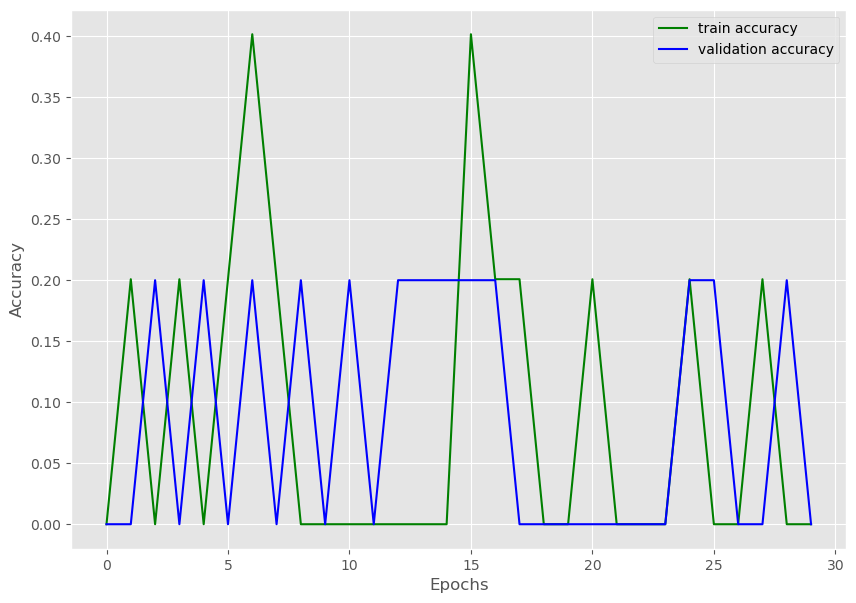

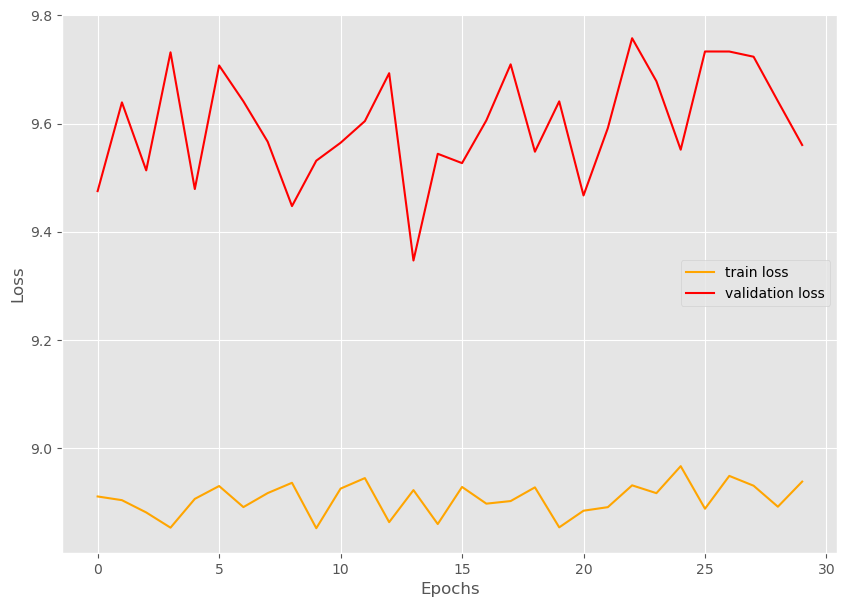

Saving model...
TRAINING COMPLETE


In [61]:
print('Saving loss and accuracy plots...')

plt.figure(figsize=(10, 7))
plt.plot(train_accuracy, color='green', label='train accuracy')  # 훈련 데이터셋에 대한 정확도를 그래프로 출력
plt.plot(val_accuracy, color='blue', label='validation accuracy')  # 검증 데이터셋에 대한 정확도를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"img/{acc_plot_name}.png")
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(train_loss, color='orange', label='train loss')  # 훈련 데이터셋에 대한 오차를 그래프로 출력
plt.plot(val_loss, color='red', label='validation loss')  # 검증 데이터셋에 대한 오차를 그래프로 출력
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.savefig(f"img/{loss_plot_name}.png")
plt.show()

print('Saving model...')
torch.save(model.state_dict(), f"img/{model_name}.pth")  # 모델을 저장
print('TRAINING COMPLETE')
